<a href="https://colab.research.google.com/github/morozovsolncev/ontology_of_synthesis/blob/main/orbita_14_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


ОНТОЛОГИЧЕСКАЯ МОДЕЛЬ ГРАВИТАЦИИ v6.1
[ПАРАМЕТРЫ] Центр: 200 вершин (p=1.6)
  Пробный: 800 вершин, сила гравитации p_inter=0.06
  Радиус усреднения: 5.0, орбита: 6.0
  Запуск из точки (6.0, 0) со скоростью 1.549

[ДВИЖЕНИЕ] Запуск симуляции...
  шаг    0: r=5.998, v=1.547, ρ_center=10660
  шаг  200: r=5.866, v=1.815, ρ_center=29260
  шаг  400: r=4.140, v=2.300, ρ_center=215820
  шаг  600: r=5.684, v=1.799, ρ_center=20825
  шаг  800: r=6.296, v=1.594, ρ_center=12341
  шаг 1000: r=5.084, v=2.058, ρ_center=76076
  шаг 1200: r=4.000, v=2.422, ρ_center=410040
  шаг 1400: r=5.065, v=2.069, ρ_center=67525
  шаг 1600: r=6.603, v=1.372, ρ_center=8436
  шаг 1800: r=4.724, v=2.039, ρ_center=134044

[ЗАВЕРШЕНО] за 413.5 сек, 2000 шагов

[ВИЗУАЛИЗАЦИЯ] Построение статической карты...
  Сохранено как gravity_orbits_static.png


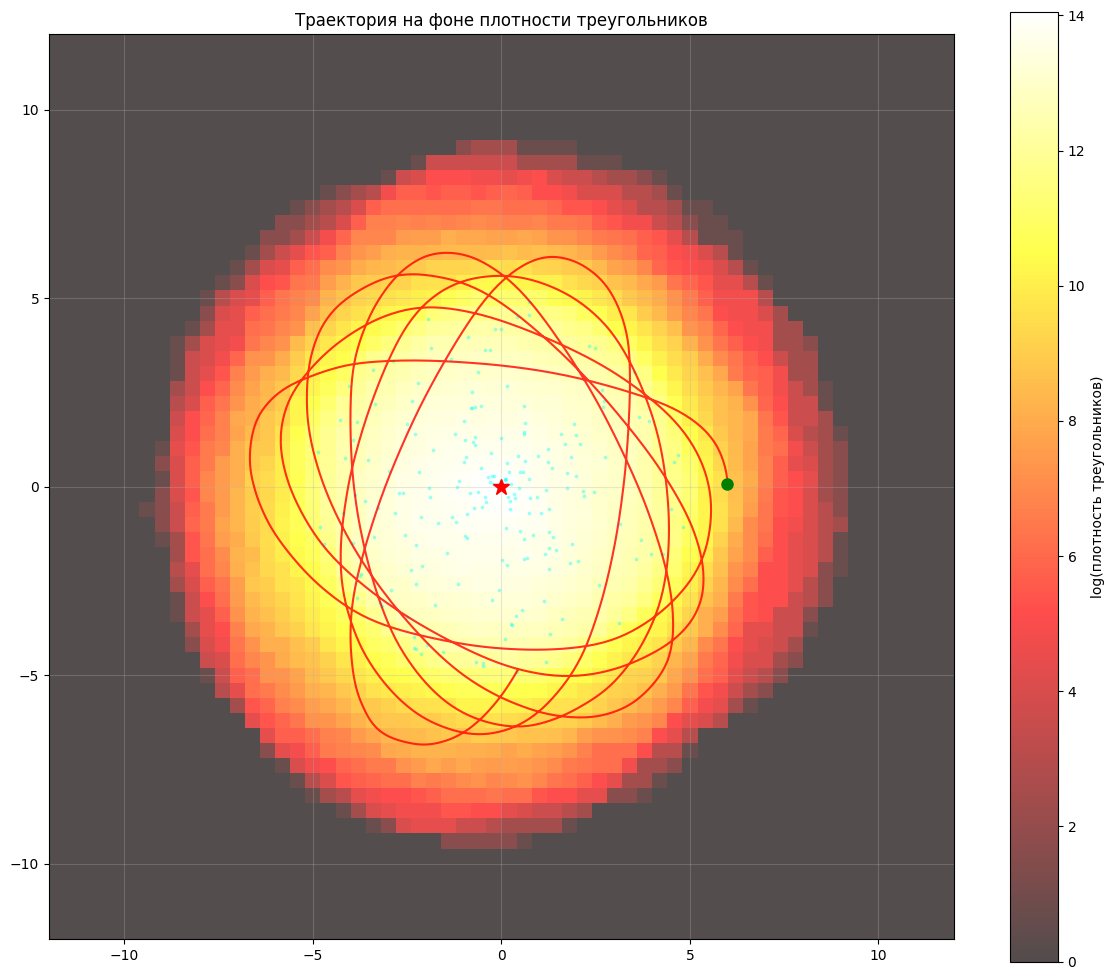


[ВИЗУАЛИЗАЦИЯ] Создание анимации...
  Построение карты плотности...
  Кадров: 200 (всего шагов: 2000)
  Анимация сохранена как gravity_orbits.gif

[ГОТОВО] Файлы: gravity_orbits_static.png, gravity_orbits.gif


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ОНТОЛОГИЧЕСКАЯ МОДЕЛЬ ГРАВИТАЦИИ v6.1
Исправление: правильные параметры для орбиты
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.spatial import KDTree
import time

class UnifiedGravityModel:
    def __init__(self, n_center=200, n_shell=800,
                 p_center=1.6, p_shell=0.01, p_inter=0.06,
                 center_radius=5.0, shell_radius=0.5, shell_orbit=6.0,
                 avg_radius=5.0, seed=45):

        print("\n" + "="*70)
        print("ОНТОЛОГИЧЕСКАЯ МОДЕЛЬ ГРАВИТАЦИИ v6.1")
        print("="*70)

        self.n_center = n_center
        self.n_shell = n_shell
        self.n_total = n_center + n_shell

        self.p_center = p_center
        self.p_shell = p_shell
        self.p_inter = p_inter
        self.avg_radius = avg_radius

        if seed is not None:
            np.random.seed(seed)

        print(f"[ПАРАМЕТРЫ] Центр: {n_center} вершин (p={p_center})")
        print(f"  Пробный: {n_shell} вершин, сила гравитации p_inter={p_inter}")
        print(f"  Радиус усреднения: {avg_radius}, орбита: {shell_orbit}")

        # Позиции
        self.positions = np.zeros((self.n_total, 2))

        # Центральный кластер
        for i in range(n_center):
            r = np.random.random() * center_radius
            theta = np.random.random() * 2 * np.pi
            self.positions[i] = [r * np.cos(theta), r * np.sin(theta)]

        # Пробный кластер
        self.shell_center = np.array([shell_orbit, 0.0])
        for i in range(n_center, self.n_total):
            r = np.random.random() * shell_radius
            theta = np.random.random() * 2 * np.pi
            local_pos = np.array([r * np.cos(theta), r * np.sin(theta)])
            self.positions[i] = self.shell_center + local_pos

        # Связи
        self.adj = np.zeros((self.n_total, self.n_total), dtype=bool)
        self.init_connections()

        # Два отдельных дерева
        self.kdtree_center = KDTree(self.positions[:n_center])
        self.kdtree_shell = KDTree(self.positions[n_center:])

        v_circular = np.sqrt(p_inter * 40)
        self.shell_velocity = np.array([0.0, v_circular])

        self.history = {'x': [], 'y': [], 'vx': [], 'vy': [], 'r': [], 'angle': []}

        print(f"  Запуск из точки ({shell_orbit}, 0) со скоростью {v_circular:.3f}\n")

    def init_connections(self):
        center_indices = range(self.n_center)
        shell_indices = range(self.n_center, self.n_total)

        for i in center_indices:
            for j in center_indices:
                if i < j and np.random.random() < self.p_center:
                    self.adj[i][j] = self.adj[j][i] = True

        for i in shell_indices:
            for j in shell_indices:
                if i < j and np.random.random() < self.p_shell:
                    self.adj[i][j] = self.adj[j][i] = True

        for i in center_indices:
            for j in shell_indices:
                if np.random.random() < self.p_inter:
                    self.adj[i][j] = self.adj[j][i] = True

    def count_triangles_in_region_center(self, center, radius):
        """Подсчёт треугольников ТОЛЬКО в центральном кластере"""
        indices = self.kdtree_center.query_ball_point(center, radius)
        if len(indices) < 3:
            return 0

        triangles = 0
        for idx_i, i in enumerate(indices):
            for idx_j, j in enumerate(indices[idx_i+1:], start=idx_i+1):
                if self.adj[i][j]:
                    for k in indices[idx_j+1:]:
                        if self.adj[i][k] and self.adj[j][k]:
                            triangles += 1
        return triangles

    def compute_potential_center(self, point):
        """Потенциал ТОЛЬКО от центрального кластера"""
        return self.count_triangles_in_region_center(point, self.avg_radius)

    def compute_potential_total(self, point):
        """Полный потенциал (для визуализации фона)"""
        center = self.count_triangles_in_region_center(point, self.avg_radius)
        shell = self.count_triangles_in_region_shell(point, self.avg_radius)
        return center + shell

    def count_triangles_in_region_shell(self, center, radius):
        """Подсчёт треугольников в пробном кластере"""
        indices = self.kdtree_shell.query_ball_point(center, radius)
        if len(indices) < 3:
            return 0

        triangles = 0
        for idx_i, i in enumerate(indices):
            for idx_j, j in enumerate(indices[idx_i+1:], start=idx_i+1):
                if self.adj[i][j]:
                    for k in indices[idx_j+1:]:
                        if self.adj[i][k] and self.adj[j][k]:
                            triangles += 1
        return triangles

    def find_resonance_target(self, point, radius=10.0):
        """
        Находит точку максимальной вероятности резонанса
        Ищет ТОЛЬКО в центральном кластере
        """
        center_indices = range(self.n_center)
        best_i = None
        best_prob = 0
        best_pos = None

        # Плотность в точке (от центрального кластера)
        rho_center = self.compute_potential_center(point)
        density_factor = np.log1p(rho_center) / (np.log1p(rho_center) + 10)

        for i in center_indices:
            d = np.linalg.norm(self.positions[i] - point)
            if d < radius:
                rho_at_vertex = self.count_triangles_in_region_center(self.positions[i], 2.0)
                vertex_factor = np.log1p(rho_at_vertex) / (np.log1p(rho_at_vertex) + 10)
                distance_factor = np.exp(-d / radius)
                prob = distance_factor * density_factor * vertex_factor

                if prob > best_prob:
                    best_prob = prob
                    best_i = i
                    best_pos = self.positions[i].copy()

        if best_pos is None:
            max_rho = 0
            for i in center_indices:
                rho_v = self.count_triangles_in_region_center(self.positions[i], 2.0)
                if rho_v > max_rho:
                    max_rho = rho_v
                    best_pos = self.positions[i].copy()

        return best_pos, best_prob

    def compute_force_vector(self, point, delta=0.3):
        """Вычисляет вектор силы ТОЛЬКО от центрального кластера"""
        x, y = point
        rho0 = self.compute_potential_center([x, y])
        if rho0 < 1:
            return np.array([0.0, 0.0]), np.array([0.0, 0.0])

        rho_x_plus = self.compute_potential_center([x + delta, y])
        rho_x_minus = self.compute_potential_center([x - delta, y])
        rho_y_plus = self.compute_potential_center([x, y + delta])
        rho_y_minus = self.compute_potential_center([x, y - delta])

        grad_x = (np.log(max(rho_x_plus, 1)) - np.log(max(rho_x_minus, 1))) / (2 * delta)
        grad_y = (np.log(max(rho_y_plus, 1)) - np.log(max(rho_y_minus, 1))) / (2 * delta)

        force = np.array([grad_x, grad_y]) * 0.5

        force_norm = np.linalg.norm(force)
        if force_norm > 0:
            direction = force / force_norm
        else:
            direction = np.array([0.0, 0.0])

        return force, direction

    def step(self, dt=0.05):
        force, _ = self.compute_force_vector(self.shell_center)
        self.shell_velocity += force * dt
        self.shell_center += self.shell_velocity * dt

        r = np.linalg.norm(self.shell_center)
        angle = np.arctan2(self.shell_center[1], self.shell_center[0])

        self.history['x'].append(self.shell_center[0])
        self.history['y'].append(self.shell_center[1])
        self.history['vx'].append(self.shell_velocity[0])
        self.history['vy'].append(self.shell_velocity[1])
        self.history['r'].append(r)
        self.history['angle'].append(angle)

        return force

    def run(self, steps=2000, dt=0.05, verbose=True):
        print("[ДВИЖЕНИЕ] Запуск симуляции...")
        start = time.time()

        for step in range(steps):
            force = self.step(dt)

            if verbose and step % 200 == 0:
                r = self.history['r'][-1]
                v = np.linalg.norm(self.shell_velocity)
                rho = self.compute_potential_center(self.shell_center)
                print(f"  шаг {step:4d}: r={r:.3f}, v={v:.3f}, ρ_center={rho:.0f}")

        elapsed = time.time() - start
        print(f"\n[ЗАВЕРШЕНО] за {elapsed:.1f} сек, {len(self.history['x'])} шагов")

    def create_animation(self, step_skip=10, max_frames=200, save_as='gravity_orbits.gif'):
        print("\n[ВИЗУАЛИЗАЦИЯ] Создание анимации...")

        print("  Построение карты плотности...")
        x = np.linspace(-12, 12, 60)
        y = np.linspace(-12, 12, 60)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X)

        for i in range(len(x)):
            for j in range(len(y)):
                Z[j, i] = self.compute_potential_center([X[j, i], Y[j, i]])

        Z_log = np.log1p(Z)

        all_steps = len(self.history['x'])
        step_indices = list(range(0, all_steps, step_skip))
        if len(step_indices) > max_frames:
            step_indices = step_indices[:max_frames]

        print(f"  Кадров: {len(step_indices)} (всего шагов: {all_steps})")

        fig, ax = plt.subplots(figsize=(12, 10))

        im = ax.imshow(Z_log, extent=[-12, 12, -12, 12], origin='lower',
                       cmap='hot', alpha=0.6, vmin=0, vmax=np.percentile(Z_log, 95))
        plt.colorbar(im, ax=ax, label='log(плотность треугольников)')

        ax.scatter(self.positions[:self.n_center, 0],
                   self.positions[:self.n_center, 1],
                   c='cyan', s=3, alpha=0.5, label='потенции центра')

        ax.scatter(self.positions[self.n_center:, 0],
                   self.positions[self.n_center:, 1],
                   c='gray', s=1, alpha=0.2, label='потенции пробного')

        particle, = ax.plot([], [], 'ro', markersize=12, label='пробное тело')
        resonance_line, = ax.plot([], [], 'lime', linewidth=2.5, alpha=0.9, label='резонанс')
        trajectory, = ax.plot([], [], 'r-', linewidth=1.5, alpha=0.6)

        ax.set_xlim(-12, 12)
        ax.set_ylim(-12, 12)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title('Гравитация в онтологии синтеза\n'
                     'Зелёная линия — резонанс с областью max плотности',
                     fontsize=11)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.set_aspect('equal')

        text_box = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                          fontsize=9, verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        def animate(idx):
            frame = step_indices[idx]
            x_pos = self.history['x'][frame]
            y_pos = self.history['y'][frame]

            particle.set_data([x_pos], [y_pos])
            trajectory.set_data(self.history['x'][:frame+1], self.history['y'][:frame+1])

            target, prob = self.find_resonance_target(np.array([x_pos, y_pos]), radius=10.0)
            if target is not None:
                resonance_line.set_data([x_pos, target[0]], [y_pos, target[1]])
                if prob > 0.4:
                    resonance_line.set_color('lime')
                elif prob > 0.2:
                    resonance_line.set_color('yellow')
                else:
                    resonance_line.set_color('orange')
            else:
                resonance_line.set_data([], [])

            r = self.history['r'][frame]
            v = np.sqrt(self.history['vx'][frame]**2 + self.history['vy'][frame]**2)
            rho = self.compute_potential_center([x_pos, y_pos])

            text_box.set_text(
                f"шаг: {frame}\n"
                f"r: {r:.2f}\n"
                f"v: {v:.2f}\n"
                f"ρ_center: {rho:.0f}\n"
                f"резонанс: {prob:.2f}"
            )

            return [particle, trajectory, resonance_line, text_box]

        ani = animation.FuncAnimation(fig, animate, frames=len(step_indices),
                                      interval=50, blit=False, repeat=False)

        ani.save(save_as, writer='pillow', fps=15, dpi=100)
        print(f"  Анимация сохранена как {save_as}")

        plt.close(fig)
        return ani

    def plot_static(self):
        print("\n[ВИЗУАЛИЗАЦИЯ] Построение статической карты...")

        x = np.linspace(-12, 12, 60)
        y = np.linspace(-12, 12, 60)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X)

        for i in range(len(x)):
            for j in range(len(y)):
                Z[j, i] = self.compute_potential_center([X[j, i], Y[j, i]])

        fig, ax = plt.subplots(figsize=(12, 10))

        im = ax.imshow(np.log1p(Z), extent=[-12, 12, -12, 12], origin='lower',
                       cmap='hot', alpha=0.7)
        plt.colorbar(im, ax=ax, label='log(плотность треугольников)')

        ax.scatter(self.positions[:self.n_center, 0],
                   self.positions[:self.n_center, 1],
                   c='cyan', s=3, alpha=0.3)

        ax.plot(self.history['x'], self.history['y'], 'r-', linewidth=1.5, alpha=0.8)
        ax.plot(self.history['x'][0], self.history['y'][0], 'go', markersize=8)
        ax.plot(0, 0, 'r*', markersize=12)

        ax.set_xlim(-12, 12)
        ax.set_ylim(-12, 12)
        ax.set_title('Траектория на фоне плотности треугольников')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')

        plt.tight_layout()
        plt.savefig('gravity_orbits_static.png', dpi=150)
        print("  Сохранено как gravity_orbits_static.png")
        plt.show()


# ============================================================
# ЗАПУСК
# ============================================================

if __name__ == "__main__":
    model = UnifiedGravityModel(
        n_center=200, n_shell=800,
        p_center=1.6, p_shell=0.01, p_inter=0.06,
        center_radius=5.0, shell_radius=0.5, shell_orbit=6.0,
        avg_radius=5.0, seed=45
    )

    model.run(steps=2000, dt=0.05, verbose=True)
    model.plot_static()
    model.create_animation(step_skip=10, max_frames=200, save_as='gravity_orbits.gif')

    print("\n[ГОТОВО] Файлы: gravity_orbits_static.png, gravity_orbits.gif")